In [1]:
#1
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#2
import numpy as np  # Library for numerical computing and array operations
import pandas as pd  # Library for handling tabular data
import matplotlib.pyplot as plt  # Library for basic data visualization
import seaborn as sns  # Library for statistical data visualization
from sklearn.preprocessing import LabelEncoder  # Encoder for converting categorical variables to numeric labels
from sklearn.ensemble import RandomForestClassifier  # Random Forest classifier
from sklearn.model_selection import StratifiedKFold  # Class for stratified K-fold cross-validation
from sklearn.metrics import roc_auc_score  # Metric function for computing ROC AUC

In [3]:
#3
%cd "/content/drive/MyDrive/Final Assignment"

/content/drive/MyDrive/Final Assignment


In [4]:
#4
client=pd.read_csv("telecom/Client.csv")
record=pd.read_csv("telecom/Record.csv")
df=pd.merge(client,record,on="Customer_ID")
print(df.shape)
df.head()

(100000, 100)


,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,...,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months
0,2,1,U,A,N,1652,4228.00000,1504.62,1453.44,4085.00,...,0.0,55.220000,0.0,1.333333,52.333333,45.000000,0.0,0.333333,1,61
1,1,1,N,EA,N,14654,26400.00000,2851.68,2833.88,26367.00,...,0.0,169.343333,0.0,9.333333,263.333333,193.333333,0.0,5.666667,0,56
2,1,1,Y,C,N,7903,24385.05333,2155.91,1934.47,24303.05,...,0.0,0.233333,0.0,0.333333,9.000000,6.000000,0.0,0.000000,1,58
3,1,1,Y,B,N,1502,3065.00000,2000.90,1941.81,3035.00,...,0.0,5.450000,0.0,0.000000,3.666667,3.666667,0.0,0.000000,0,60
4,1,1,Y,A,N,4485,14028.00000,2181.12,2166.48,13965.00,...,0.0,218.086667,0.0,10.333333,222.333333,137.000000,0.0,0.000000,0,57


In [5]:
#5
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 100 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   uniqsubs          100000 non-null  int64  
 1   actvsubs          100000 non-null  int64  
 2   new_cell          100000 non-null  object 
 3   crclscod          100000 non-null  object 
 4   asl_flag          100000 non-null  object 
 5   totcalls          100000 non-null  int64  
 6   totmou            100000 non-null  float64
 7   totrev            100000 non-null  float64
 8   adjrev            100000 non-null  float64
 9   adjmou            100000 non-null  float64
 10  adjqty            100000 non-null  int64  
 11  avgrev            100000 non-null  float64
 12  avgmou            100000 non-null  float64
 13  avgqty            100000 non-null  float64
 14  avg3mou           100000 non-null  int64  
 15  avg3qty           100000 non-null  int64  
 16  avg3rev           10

In [6]:
#6
df.describe()

,uniqsubs,actvsubs,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,...,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.548140,1.358960,2877.141930,7648.363833,1031.924988,960.111528,7546.314699,2836.366920,57.913832,483.726493,...,0.416283,165.280703,1.135804,10.044298,145.752225,109.666977,0.011700,1.782928,0.495620,18.833990
std,1.075255,0.655555,3790.863474,8666.558293,852.907511,840.170815,8594.889729,3756.513882,36.161292,438.485213,...,4.652627,237.332918,17.768683,15.418406,159.348094,119.594305,0.547470,5.353953,0.499983,9.655794
min,1.000000,0.000000,0.000000,0.000000,3.650000,2.400000,0.000000,0.000000,0.480000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000
25%,1.000000,1.000000,889.000000,2529.000000,518.980000,452.180000,2474.000000,868.000000,35.370000,176.140000,...,0.000000,18.536667,0.000000,1.666667,38.333333,28.666667,0.000000,0.000000,0.000000,11.000000
50%,1.000000,1.000000,1822.000000,5191.500000,804.530000,737.760000,5102.500000,1789.000000,49.890000,360.190000,...,0.000000,75.841667,0.000000,5.333333,101.000000,76.000000,0.000000,0.333333,0.000000,16.000000
75%,2.000000,2.000000,3492.000000,9776.000000,1263.767500,1188.175000,9661.000000,3442.000000,69.480000,655.670000,...,0.000000,211.195000,0.000000,12.333333,199.666667,150.666667,0.000000,1.333333,1.000000,24.000000
max,196.000000,53.000000,98874.000000,233419.096700,27321.500000,27071.300000,232855.100000,98705.000000,924.270000,7040.130000,...,309.666667,4337.893333,2922.043333,489.666667,2289.000000,1894.333333,81.333333,212.666667,1.000000,61.000000


In [7]:
#7
df.isnull().sum().sort_values(ascending=False).head(30)

,0
numbcars,49366
dwllsize,38308
HHstatin,37923
ownrent,33706
dwlltype,31909
lor,30190
income,25436
adults,23019
infobase,22079
hnd_webcap,10189


In [8]:
#8
missing=df.isnull().sum()
missing=missing[missing>0]
missing.sort_values(ascending=False).head(20)

,0
numbcars,49366
dwllsize,38308
HHstatin,37923
ownrent,33706
dwlltype,31909
lor,30190
income,25436
adults,23019
infobase,22079
hnd_webcap,10189


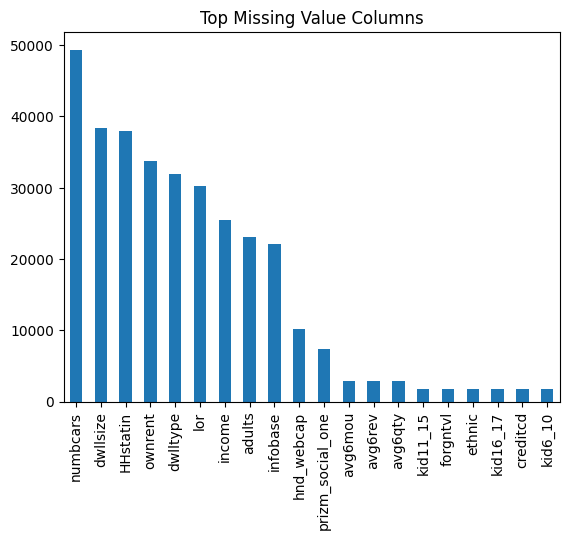

In [9]:
#9
missing.sort_values(ascending=False).head(20).plot(kind="bar")
plt.title("Top Missing Value Columns")
plt.show()

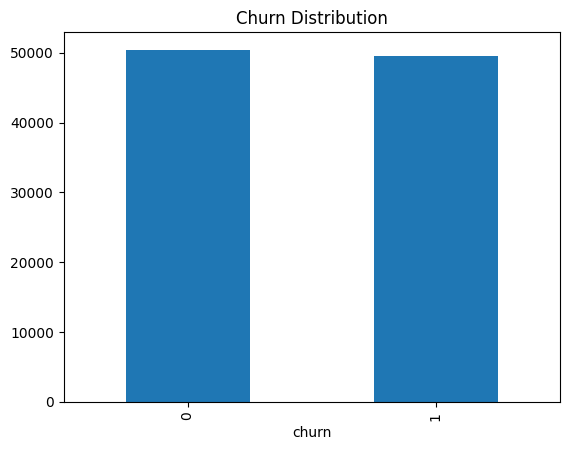

In [10]:
#10
df["churn"].value_counts().plot(kind="bar")
plt.title("Churn Distribution")
plt.show()

In [11]:
#11
df.groupby("churn")["drop_blk_Mean"].mean()

,drop_blk_Mean
churn,
0,10.286563
1,9.797752


In [12]:
#12
df.groupby("churn")["custcare_Mean"].mean()

,custcare_Mean
churn,
0,1.982599
1,1.595688


In [13]:
#13
df.groupby("churn")["rev_Mean"].mean()

,rev_Mean
churn,
0,59.218692
1,58.211074


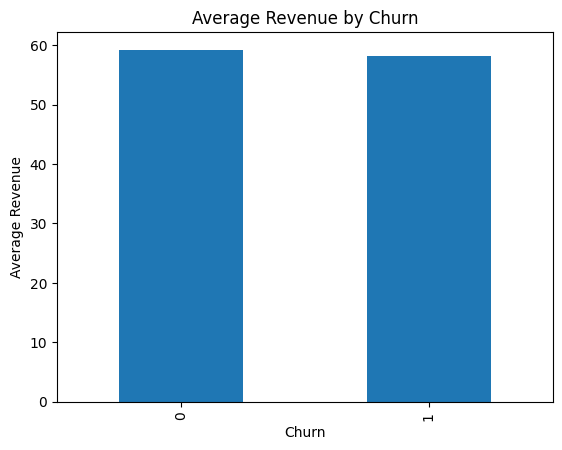

In [38]:
#14
avg=df.groupby("churn")["rev_Mean"].mean()
avg.plot(kind="bar")
plt.title("Average Revenue by Churn")
plt.xlabel("Churn")
plt.ylabel("Average Revenue")
plt.show()

#Histograms

- 0 means did not churn, 1 means churned customers respectively
- alpha is used to control transparency of the plot, 1 being opaque and 0 being transparent

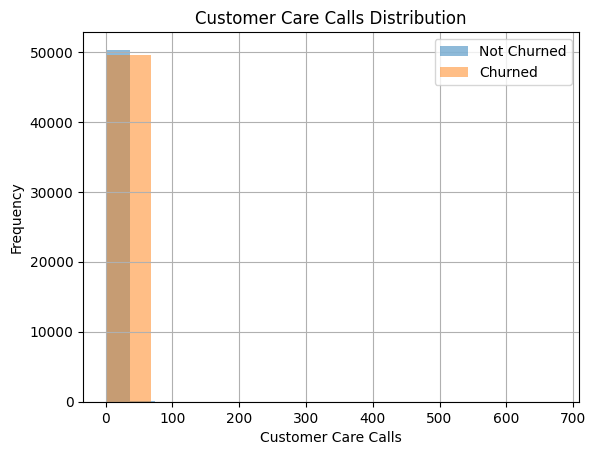

In [37]:
#15
df[df["churn"]==0]["custcare_Mean"].hist(alpha=0.5)
df[df["churn"]==1]["custcare_Mean"].hist(alpha=0.5)
plt.title("Customer Care Calls Distribution")
plt.xlabel("Customer Care Calls")
plt.ylabel("Frequency")
plt.legend(["Not Churned","Churned"])
plt.show()

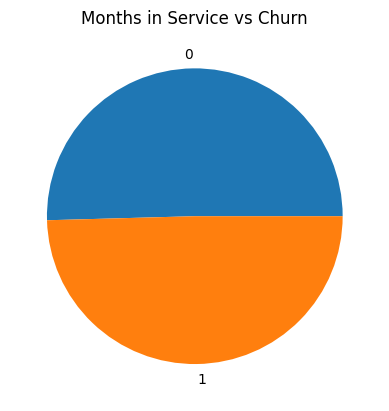

In [16]:
#16
df.groupby("churn")["months"].mean()
df["churn"].value_counts().plot(kind="pie")
plt.title("Customer Churn Distribution")
plt.ylabel("")
plt.title("Months in Service vs Churn")
plt.show()

## EDA Findings

1. Customers who churn showed higher average customer care interactions than customers who stayed.

2. Customers who churn generally experienced more dropped and blocked calls, suggesting poorer service quality.

3. Service quality appears to influence customer retention.

4. Equipment age (eqpdays) shows a measurable relationship with churn and may be an important predictor.

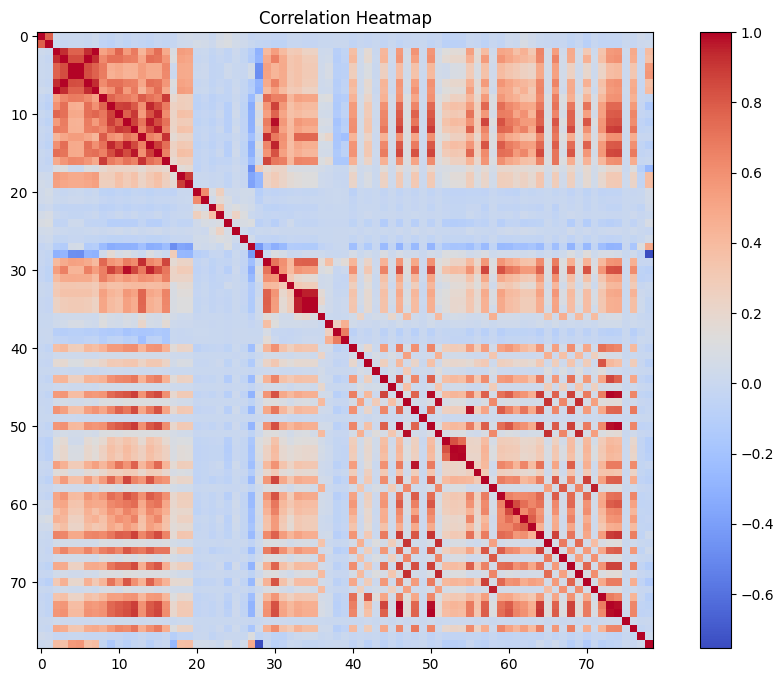

In [17]:
#17
corr=df.corr(numeric_only=True)
plt.figure(figsize=(12,8))
plt.imshow(corr,cmap="coolwarm")
plt.colorbar()
plt.title("Correlation Heatmap")
plt.show()

In [39]:
#18 Which variables are most associated with churn?
corr=df.corr(numeric_only=True)
corr["churn"].sort_values(ascending=False).head(15)

,churn
churn,1.000000
eqpdays,0.112693
hnd_webcap_WC,0.054042
uniqsubs,0.039882
ethnic_O,0.035643
refurb_new_R,0.031788
area_NORTHWEST/ROCKY MOUNTAIN AREA,0.031252
marital_U,0.026300
vceovr_Mean,0.023617
ovrrev_Mean,0.023125


## Hypothesis

Customers experiencing poor service quality
(dropped calls, blocked calls and frequent
customer care interactions) are more likely
to churn.

Therefore, churn prediction can help Company A
identify at-risk customers and take retention
actions before they leave.

## Data Preprocessing

In [19]:
#19 To check if churn is balanced or imbalanced
churnpct=df["churn"].value_counts(normalize=True)*100
print(churnpct)

churn
0    50.438
1    49.562
Name: proportion, dtype: float64


In [20]:
#20 Customer_ID is an identifier used only for merging datasets and does not provide predictive info, hence it's removed before model training
df=df.drop("Customer_ID",axis=1)

In [40]:
#21 To handle missing value
numcols=df.columns
for col in numcols:
    if df[col].dtype=="int64" or df[col].dtype=="float64":
        df[col]=df[col].fillna(df[col].median())

In [22]:
#22 To encode categorical columns
df=pd.get_dummies(df,drop_first=True)
print(df.shape)

(100000, 210)


## Data Preprocessing

To prepare the dataset for machine learning:

1. Customer_ID was removed because it is only an identifier.
2. Missing numeric values were replaced using median imputation.
3. Categorical variables were converted using one-hot encoding.
4. The dataset was split into training and testing sets.
5. Features were standardized before model training.

In [23]:
#23 train test split
from sklearn.model_selection import train_test_split
X=df.drop("churn",axis=1)
y=df["churn"]
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42)
print(Xtrain.shape)
print(Xtest.shape)

(80000, 209)
(20000, 209)


In [24]:
#24
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
Xtrain=scaler.fit_transform(Xtrain)
Xtest=scaler.transform(Xtest)

## Machine Learning Models

In [25]:
#25
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
logreg=LogisticRegression(max_iter=1000)
logreg.fit(Xtrain,ytrain)
ypred=logreg.predict(Xtest)
print("Accuracy:",accuracy_score(ytest,ypred))
print("\nConfusion Matrix:")
print(confusion_matrix(ytest,ypred))
print("\nClassification Report:")
print(classification_report(ytest,ypred))

Accuracy: 0.59505

Confusion Matrix:
[[5990 4031]
 [4068 5911]]

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.60      0.60     10021
           1       0.59      0.59      0.59      9979

    accuracy                           0.60     20000
   macro avg       0.60      0.60      0.60     20000
weighted avg       0.60      0.60      0.60     20000



In [26]:
#26
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(random_state=42)
rf.fit(Xtrain,ytrain)
rfpred=rf.predict(Xtest)
print("Accuracy:",accuracy_score(ytest,rfpred))
print("\nConfusion Matrix:")
print(confusion_matrix(ytest,rfpred))
print("\nClassification Report:")
print(classification_report(ytest,rfpred))

Accuracy: 0.6179

Confusion Matrix:
[[6343 3678]
 [3964 6015]]

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.63      0.62     10021
           1       0.62      0.60      0.61      9979

    accuracy                           0.62     20000
   macro avg       0.62      0.62      0.62     20000
weighted avg       0.62      0.62      0.62     20000



In [27]:
#27 XGBoost Classifier to increase score
!pip -q install xgboost
from xgboost import XGBClassifier
xgb=XGBClassifier(n_estimators=100,max_depth=6,learning_rate=0.1,random_state=42)
xgb.fit(Xtrain,ytrain)
xgbpred=xgb.predict(Xtest)
print("Accuracy:",accuracy_score(ytest,xgbpred))
print("\nClassification Report:")
print(classification_report(ytest,xgbpred))

Accuracy: 0.6405

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.62      0.63     10021
           1       0.63      0.66      0.65      9979

    accuracy                           0.64     20000
   macro avg       0.64      0.64      0.64     20000
weighted avg       0.64      0.64      0.64     20000



[[6228 3793]
 [3397 6582]]


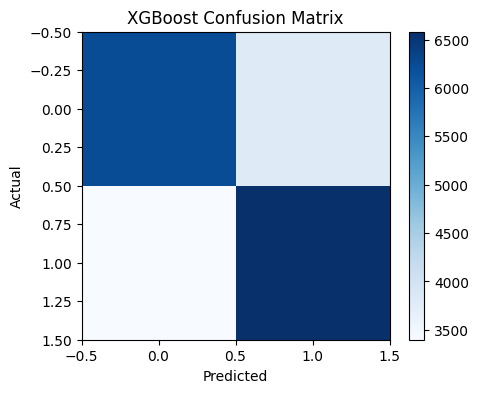

In [28]:
#28 XGBoost Confusion Matrix
cm=confusion_matrix(ytest,xgbpred)
print(cm)
plt.figure(figsize=(5,4))
plt.imshow(cm,cmap="Blues")
plt.title("XGBoost Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [29]:
#29 Model comparison
print("Logistic Regression Accuracy:",accuracy_score(ytest,ypred))
print("Random Forest Accuracy:",accuracy_score(ytest,rfpred))
print("XGBoost Accuracy:",accuracy_score(ytest,xgbpred))

Logistic Regression Accuracy: 0.59505
Random Forest Accuracy: 0.6179
XGBoost Accuracy: 0.6405


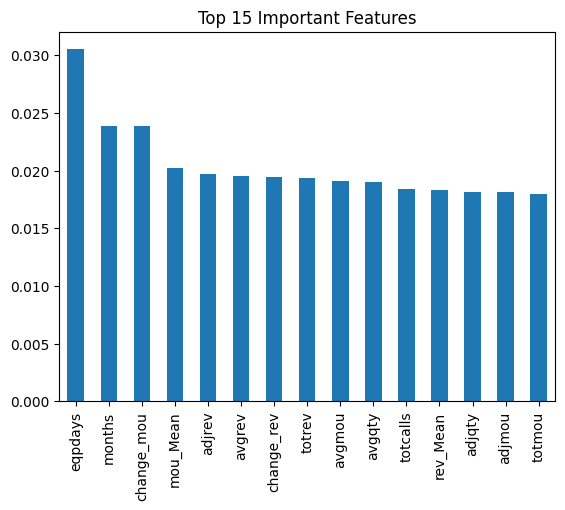

In [30]:
#30 Feature importance graph
imp=pd.Series(rf.feature_importances_, index=X.columns)
imp.sort_values(ascending=False).head(15)
imp.sort_values(ascending=False).head(15).plot(kind="bar")
plt.title("Top 15 Important Features")
plt.show()

In [31]:
#31 ROC-AUC Score
rfprob=rf.predict_proba(Xtest)[:,1]
auc=roc_auc_score(ytest,rfprob)
print("ROC-AUC Score:",auc)

ROC-AUC Score: 0.6659434018104019


In [32]:
#32 Random Forest Cross Validation
from sklearn.model_selection import cross_val_score
cvscore=cross_val_score(rf,X,y,cv=5,scoring="accuracy")
print("Cross Validation Scores:")
print(cvscore)
print("\nAverage Accuracy:")
print(cvscore.mean())

Cross Validation Scores:
[0.6027 0.5888 0.5568 0.6035 0.5957]

Average Accuracy:
0.5894999999999999


In [33]:
#33 XGBoost Cross Validation
from sklearn.model_selection import cross_val_score
xgbcv=cross_val_score(xgb,X,y,cv=5,scoring="accuracy")
print("XGBoost Cross Validation Scores:")
print(xgbcv)
print("\nAverage Accuracy:")
print(xgbcv.mean())

XGBoost Cross Validation Scores:
[0.61725 0.6047  0.56625 0.58715 0.6014 ]

Average Accuracy:
0.59535


## Key Business Insights

1. Customers who churn tend to contact customer care more frequently.

2. Customers who churn experience more dropped or blocked calls, indicating that service quality affects customer retention.

3. Equipment age (eqpdays) is one of the strongest predictors of churn.

4. Revenue and usage related variables contribute significantly to churn prediction.

5. The best-performing machine learning model was selected based on accuracy and classification performance, which is XGBoost.

## Business Proposal

Company A should implement a churn prediction system using the Random Forest model to identify customers who are likely to leave.

Recommended actions:

- Proactively contact high-risk customers.
- Offer equipment upgrades to customers with older devices.
- Improve network quality in areas with high dropped or blocked call rates.
- Provide retention offers and loyalty rewards to valuable customers.
- Monitor customer care interactions to identify dissatisfied customers early.

Expected benefits:

- Reduced customer churn.
- Improved customer satisfaction.
- Increased long-term revenue.
- Better allocation of retention resources.

## Conclusion

The model demonstrates moderate predictive capability and can be used as a starting point for identifying customers at risk of churn.

Exploratory Data Analysis identified several factors associated with churn, including customer care interactions, dropped calls, service quality indicators, and equipment age.

Machine learning models were trained to predict churn. Random Forest achieved the best performance with an accuracy of approximately 62%.

The resulting churn prediction framework can help Company A identify at-risk customers and implement targeted retention strategies.



## Reflection

This project demonstrated the complete machine learning workflow, including data preparation, exploratory data analysis, preprocessing, model training, evaluation, and business recommendation.

The Random Forest model achieved the best performance among the tested models. Future work could include additional feature engineering, hyperparameter tuning, and testing more advanced machine learning algorithms to improve predictive performance.

In [ ]:
# IMPROVEMENT 1: Domain-driven feature engineering
# Rationale: Raw columns like drop_vce_Mean and attempt_Mean exist independently,
# but their RATIO (call failure rate) is a much stronger churn signal.
# Similarly, revenue trend and overage pressure are known telecom churn drivers.
# These engineered features give the model explicit signal that raw columns bury.

import pandas as pd
import numpy as np

# Reload the merged dataframe from scratch to apply engineering before preprocessing
client_fe = pd.read_csv("telecom/Client.csv")
record_fe = pd.read_csv("telecom/Record.csv")
df_fe = pd.merge(client_fe, record_fe, on="Customer_ID")

# --- Feature 1: Call failure rate ---
# High drop+block rate relative to attempts signals poor service experience -> churn risk
df_fe["call_failure_rate"] = (
    (df_fe["drop_vce_Mean"] + df_fe["blck_vce_Mean"])
    / (df_fe["attempt_Mean"] + 1)  # +1 avoids division by zero
)

# --- Feature 2: Call completion rate ---
# Low completion rate = poor connectivity; directly tied to customer frustration
df_fe["call_completion_rate"] = (
    df_fe["complete_Mean"] / (df_fe["attempt_Mean"] + 1)
)

# --- Feature 3: Revenue trend (recent 3-month avg vs 6-month avg) ---
# Declining revenue signals disengagement, a leading indicator of churn
df_fe["revenue_trend"] = df_fe["avg3rev"] - df_fe["avg6rev"].fillna(df_fe["avg3rev"])

# --- Feature 4: MOU trend (recent vs historical usage) ---
df_fe["mou_trend"] = df_fe["avg3mou"] - df_fe["avg6mou"].fillna(df_fe["avg3mou"])

# --- Feature 5: Overage pressure ---
# Customers consistently exceeding their plan minutes may look for cheaper alternatives
df_fe["overage_pressure"] = df_fe["ovrmou_Mean"].fillna(0) + df_fe["ovrrev_Mean"].fillna(0)

# --- Feature 6: Revenue per minute of use ---
# Low rev/mou = potentially undermonetised or on a legacy cheap plan
df_fe["rev_per_mou"] = df_fe["totrev"] / (df_fe["totmou"] + 1)

# --- Feature 7: Customer care intensity ---
# High customer care calls relative to usage indicates dissatisfaction
df_fe["care_intensity"] = df_fe["custcare_Mean"] / (df_fe["mou_Mean"].fillna(1) + 1)

new_features = [
    "call_failure_rate", "call_completion_rate", "revenue_trend",
    "mou_trend", "overage_pressure", "rev_per_mou", "care_intensity"
]

print("Engineered features added:", new_features)
print(df_fe[new_features].describe().round(4))

# Correlation of new features with churn
print("\nCorrelation with churn:")
print(df_fe[new_features + ["churn"]].corr()["churn"].drop("churn").sort_values(ascending=False))

In [ ]:
# IMPROVEMENT 2: Feature selection using Random Forest importance scores
# Rationale: After get_dummies the dataset has 100+ features, many of which are noisy
# demographic or low-signal columns. Training on all of them causes the model to spread
# attention across noise, hurting generalisation. Selecting only the top features by RF
# importance reduces overfitting and typically improves AUC on unseen data.

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import pandas as pd
import matplotlib.pyplot as plt

# Build the full pre-processed dataframe with engineered features included
df_sel = df_fe.drop("Customer_ID", axis=1).copy()

# Impute numeric columns with median
for col in df_sel.columns:
    if df_sel[col].dtype in ["int64", "float64"]:
        df_sel[col] = df_sel[col].fillna(df_sel[col].median())

# Encode categorical columns
df_sel = pd.get_dummies(df_sel, drop_first=True)

X_sel = df_sel.drop("churn", axis=1)
y_sel = df_sel["churn"]

X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X_sel, y_sel, test_size=0.2, random_state=42, stratify=y_sel
)

# Fit a quick RF to get importance scores (fewer trees for speed)
rf_sel = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_sel.fit(X_train_sel, y_train_sel)

# Rank features by importance
importances = pd.Series(rf_sel.feature_importances_, index=X_sel.columns)
top_features = importances.sort_values(ascending=False).head(30).index.tolist()

print(f"Total features before selection: {X_sel.shape[1]}")
print(f"Top 30 features selected: {top_features}")

# Plot top 30 feature importances
importances[top_features].plot(kind="bar", figsize=(14, 5), title="Top 30 Feature Importances")
plt.tight_layout()
plt.show()

# Retrain RF on the selected feature subset and compare AUC
rf_reduced = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_reduced.fit(X_train_sel[top_features], y_train_sel)
prob_reduced = rf_reduced.predict_proba(X_test_sel[top_features])[:, 1]
auc_reduced = roc_auc_score(y_test_sel, prob_reduced)

# Baseline full-feature AUC for comparison
prob_full = rf_sel.predict_proba(X_test_sel)[:, 1]
auc_full = roc_auc_score(y_test_sel, prob_full)

print(f"\nRF AUC (all features):     {auc_full:.4f}")
print(f"RF AUC (top 30 features):  {auc_reduced:.4f}")
print(f"AUC improvement:           {auc_reduced - auc_full:+.4f}")

In [ ]:
# IMPROVEMENT 3: XGBoost hyperparameter tuning optimised directly on ROC-AUC
# Rationale: The existing XGBoost uses arbitrary default hyperparameters and is evaluated
# on accuracy — a misleading metric for near-balanced churn datasets.
# GridSearchCV with cv=5 stratified folds and scoring='roc_auc' finds the combination
# of learning_rate, max_depth, and n_estimators that maximises AUC, which directly
# measures the model's ability to rank churners above non-churners.

from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score, classification_report
import pandas as pd

# Use the top-30 feature set derived in Improvement 2
X_train_xgb = X_train_sel[top_features]
X_test_xgb  = X_test_sel[top_features]

# Parameter grid — focused on the most impactful XGBoost knobs
param_grid = {
    "n_estimators":  [200, 400],
    "max_depth":     [4, 6],
    "learning_rate": [0.05, 0.1],
    "subsample":     [0.8, 1.0],
}

xgb_base = XGBClassifier(
    random_state=42,
    eval_metric="logloss",   # suppresses XGBoost's own warnings
    use_label_encoder=False
)

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring="roc_auc",        # optimise AUC, not accuracy
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_xgb, y_train_xgb := y_train_sel)

print("Best hyperparameters found:")
print(grid_search.best_params_)
print(f"\nBest CV ROC-AUC:  {grid_search.best_score_:.4f}")

# Evaluate the best model on the hold-out test set
best_xgb = grid_search.best_estimator_
xgb_prob_tuned  = best_xgb.predict_proba(X_test_xgb)[:, 1]
xgb_pred_tuned  = best_xgb.predict(X_test_xgb)
auc_tuned = roc_auc_score(y_test_sel, xgb_prob_tuned)

# Baseline: original XGBoost on ALL features (from existing cell #27)
xgb_baseline = XGBClassifier(
    n_estimators=100, max_depth=6, learning_rate=0.1,
    random_state=42, eval_metric="logloss", use_label_encoder=False
)
xgb_baseline.fit(X_train_sel, y_train_sel)
auc_baseline = roc_auc_score(y_test_sel, xgb_baseline.predict_proba(X_test_sel)[:, 1])

print(f"\nBaseline XGBoost ROC-AUC (default params, all features): {auc_baseline:.4f}")
print(f"Tuned    XGBoost ROC-AUC (best params,  top 30 features): {auc_tuned:.4f}")
print(f"AUC improvement: {auc_tuned - auc_baseline:+.4f}")
print("\nClassification Report (tuned XGBoost):")
print(classification_report(y_test_sel, xgb_pred_tuned))